# Joint Recurrence Plots Analysis - Phase Synchronization

## Samuel Jaramillo

### Research question
1. Compare the recurrence plot methods for detecting phase, generalised, and complete synchronisation (lag synchronisation is included).

2. Prepare an overview of the ability of the measures derived from cross- and joint recurrence plots and from tau-recurrence rate.

3. (Bonus) improve the tau-recurrence rate measure (CPR).

In [1]:
import numpy as np
import pandas as pd
import recurrence as rec
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.integrate import solve_ivp
import string

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [20]:
#Recurrence matrix updated version
def recurrence_matrix(timeseries, epsilon, transpose = False):

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                if current_value <= epsilon:
                    current_row.append(1)
                else:
                    current_row.append(0)
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        return d_matrix <= epsilon

#Recurrence matrix updated version
def recurrence_matrix_fan(timeseries, RR, transpose = False):
    nn_i = int(RR*len(timeseries))

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)

            current_row = np.array(current_row)
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        for i in range(d_matrix.shape[0]):
            current_row = d_matrix[i]
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1

            d_matrix[i] = current_row   

        return d_matrix 
    
#Recurrence matrix updated version
def cross_recurrence_matrix(timeseries1, timeseries2, epsilon, transpose = False):

    if timeseries1.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries1)):
            current_row = []
            for j in range(len(timeseries1)):
                current_value = np.abs(timeseries1[i] - timeseries2[j])
                if current_value <= epsilon:
                    current_row.append(1)
                else:
                    current_row.append(0)
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries1 = timeseries1.T
            timeseries2 = timeseries2.T

        d_matrix = cdist(timeseries1, timeseries2, metric = 'euclidean')

        return d_matrix <= epsilon
    

#Find epsilon
def optimal_epsilon(timeseries, rrate, transpose = False):
    #1-dimensional time series
    if timeseries.ndim == 1:
        d_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)  
            d_matrix.append(current_row)
    
        d_matrix = np.array(d_matrix)

    # N-dimensional time series (N>1)
    else:
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))
    #Colapse distance matrices and sort its values
    d_vector = d_matrix.flatten()

    #Sort values
    d_vector= np.sort(d_vector)

    n = int(len(d_vector)*rrate)

    return d_vector[n]

#Find CRP epsilon
def CRP_optimal_epsilon(timeseries1, timeseries2, rrate, transpose = False):
    #1-dimensional time series
    if timeseries1.ndim == 1:
        d_matrix = []
        for i in range(len(timeseries1)):
            current_row = []
            for j in range(len(timeseries1)):
                current_value = np.abs(timeseries1[i] - timeseries2[j])
                current_row.append(current_value)  
            d_matrix.append(current_row)
    
        d_matrix = np.array(d_matrix)

    # N-dimensional time series (N>1)
    else:
        #Create distance matrix
        if transpose == True:
            timeseries1 = timeseries1.T
            timeseries2 = timeseries2.T

        d_matrix = cdist(timeseries1, timeseries2, metric = 'euclidean')
    #Colapse distance matrices and sort its values
    d_vector = d_matrix.flatten()

    #Sort values
    d_vector= np.sort(d_vector)

    n = int(len(d_vector)*rrate)

    return d_vector[n]

## Phase Synchronization

In [7]:
#Import models
roessler1 = pd.read_csv('PS_Roessler1.csv').to_numpy()

roessler2 = pd.read_csv('PS_Roessler2.csv').to_numpy()

In [63]:
roessler1.shape

(10000, 3)

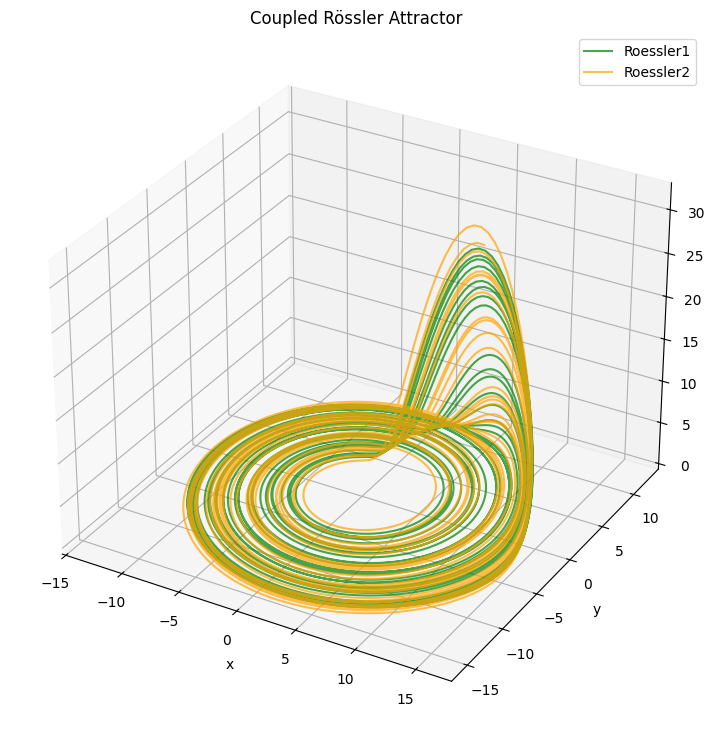

In [8]:
#Visualize models
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot(roessler1.T[0], roessler1.T[1], roessler1.T[2], alpha=0.7, label = 'Roessler1', color = 'green')
ax.plot(roessler2.T[0], roessler2.T[1], roessler2.T[2], alpha=0.7, label = 'Roessler2', color = 'orange')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title(f"Coupled Rössler Attractor")

plt.show()

In [9]:
#View individual recurrence plots
rec_roessler1 = RecurrencePlot(roessler1, recurrence_rate=0.05, metric="euclidean")

rec_roessler2 = RecurrencePlot(roessler2, recurrence_rate=0.05, metric="euclidean")

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


In [10]:
rm_1 = rec_roessler1.recurrence_matrix()
rm_2 = rec_roessler2.recurrence_matrix()

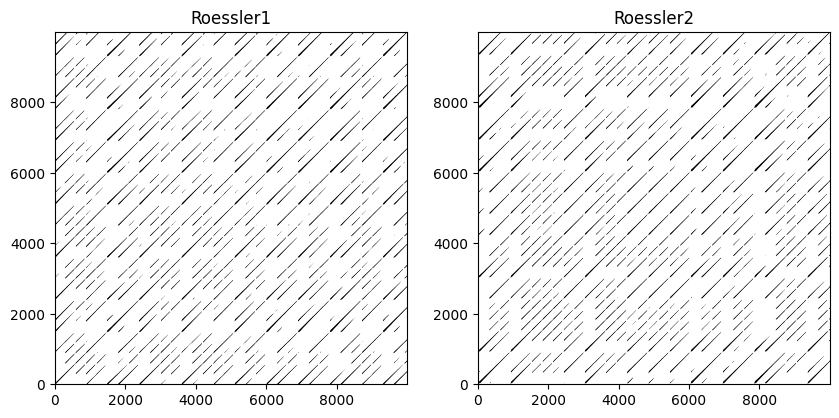

In [11]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(rm_1, origin='lower', cmap = 'binary')
axs[0].set_title('Roessler1')

axs[1].imshow(rm_2, origin='lower', cmap = 'binary')
axs[1].set_title('Roessler2')


plt.show()

Comments:
- Two systems in phase synchronization would show similar spacing between recurrences in their recurrence plots (think of the simple cases on SynchStudy.ipynb)
- Dynamics of the systems (frequency-wise) should be relatively similar because they are in PS. What differs between them is the time of the recurrences (individual lines). 
- However, the plot doesn't show clearly the phase synchronization, due to the complexity of the structure. This is where quantitative measures can be helpful.

In [12]:
#Compute JRP
PS_JR = JointRecurrencePlot(roessler1, roessler2, recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"))

RMat_PS = PS_JR.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


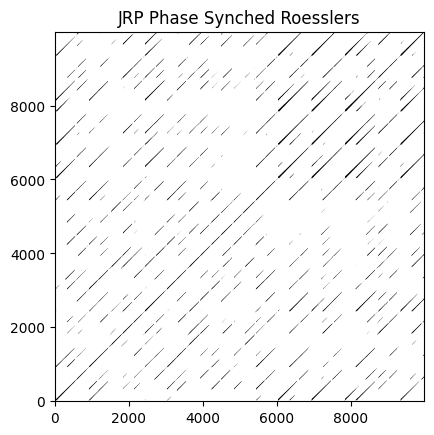

In [13]:
fig, axs = plt.subplots()

#Plot
axs.imshow(RMat_PS, origin='lower', cmap = 'binary')
axs.set_title('JRP Phase Synched Roesslers')

plt.show()

JRP
- Amplitudes don't have an influence on the JRP because we're not comparing the trajectories in phase space, but in *recurrence space*. Here, what matters is the frequency of the recurrence and the time it happened. 
- Intuitively, the fact that the JRP is not empty indicates that there is a degree of PS. Yet, there is no quantitative indicator as of now. 
- Difference between the JRPs and the individual RPs could be due to the phase difference not being completely constant, but approximately constant. Also, individual recurrences could have displacements that get annulated when multiplying the recurrence matrices for the JRPs (think of the shifts in time of individual recurrences in SynchStudy.ipynb)

Let's explore the synchronization measure:

$$
S(\tau) = \frac{JRR(\tau)}{RR}.
$$


*Note: Maybe it would be useful to include a function for this in the JointRecurrencePlot module of Pyunicorn.*

Until we agree on something, we'll analyze lags of 100 timesteps.

In [ ]:
#Takes too long
#lagged = [JointRecurrencePlot(roessler1, roessler2, recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"), lag = i) for i in range(20)]
lagged = np.array([roessler2[i:len(roessler2)-100+i] for i in range(100)])

In [30]:
eps1 = optimal_epsilon(roessler1[:-100],0.05)
rec1 = recurrence_matrix(roessler1[:-100],eps1)

In [31]:
s_tau = []

for i in range(100):
    actual_i = lagged[i]
    
    eps_i = optimal_epsilon(actual_i,0.05) 

    reci = recurrence_matrix(actual_i,eps_i)

    jrp = rec1*reci

    N = len(actual_i)


    s_tau.append((np.sum(jrp)/(N**2))/0.05)

Possible disadvantages of $S(\tau)$:
- Lagging implies shortening the timeseries, which can lead to loss of information. Make sure to have a long enough timeseries. Can be more difficult with experimental data. 
- ***Check: Does something change if we shorten time series 1 or time series 2?***

In [33]:
#lagged_RR = np.array([lagged[i].recurrence_rate() for i in range(len(lagged))])

#S_tau = lagged_RR/0.05

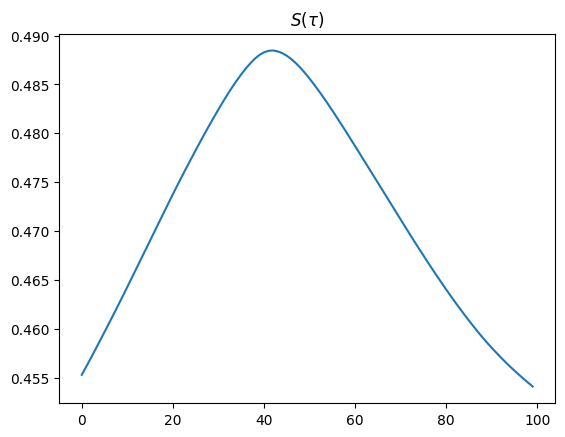

In [34]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau)
axs.set_title(r'$S(\tau)$')

plt.show()

How good is actually $S(\tau)$ for measuring PS?

Will completely PS plots show high values of $S(\tau)$?

$S(\tau)$ could show when PS is at its highest, but CPR is better.

JRP (and $S(\tau)$) will tell me if the frequencies are similar, it will tell me at which lag both RPs will be more similar, but it is highly dependent on the individual shape of the recurrences (when compared to the CPR). For instance, two time series whose phase difference is constant, but whose individual recurrences don't coincide in the recurrence plot, may show a really low $S(\tau)$.

In [44]:
#Example
PS_ex1 = 0.5*np.sin(4*np.linspace(0, 4 * np.pi, 1000)) + np.sin(np.linspace(0, 10 * np.pi, 1000))

PS_ex2 = 0.5*np.sin(4*np.linspace(0, 4 * np.pi, 1000)) + np.sin(np.linspace(0, 10 * np.pi, 1000) + np.pi/3)

In [45]:
#We don't care about the taus because we're focusing on recurrence plots and not the actual time series
rec_PS_ex1 = RecurrencePlot(PS_ex1, dim=2, tau=50, recurrence_rate=0.05, metric="euclidean")

rec_PS_ex2 = RecurrencePlot(PS_ex2, dim=2, tau=50, recurrence_rate=0.05, metric="euclidean")

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


In [46]:
rm_PS_ex1 = rec_PS_ex1.recurrence_matrix()
rm_PS_ex2 = rec_PS_ex2.recurrence_matrix()

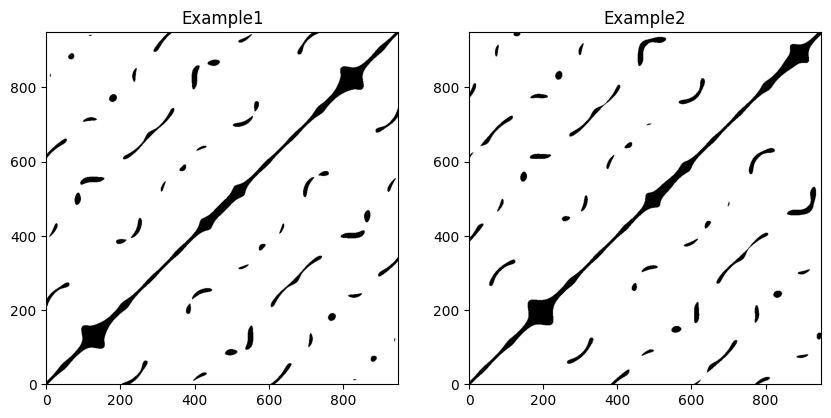

In [47]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(rm_PS_ex1, origin='lower', cmap = 'binary')
axs[0].set_title('Example1')

axs[1].imshow(rm_PS_ex2, origin='lower', cmap = 'binary')
axs[1].set_title('Example2')


plt.show()

In [ ]:
#Compute example JRP
ex_JR = JointRecurrencePlot(PS_ex1, PS_ex2, dim=(2,2), tau=(50,50), recurrence_rate=(0.05,0.05), metric=("euclidean","euclidean"))

ex_RMat = ex_JR.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


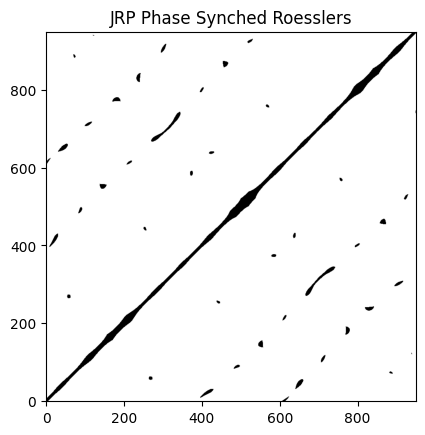

In [50]:
fig, axs = plt.subplots()

#Plot
axs.imshow(ex_RMat, origin='lower', cmap = 'binary')
axs.set_title('JRP Phase Synched Roesslers')

plt.show()

In [52]:
lagged_RR = ex_JR.recurrence_rate()

print(lagged_RR/0.05)

0.4816842105263157


In [56]:
laggedex = np.array([PS_ex2[i:len(PS_ex2)-100+i] for i in range(100)])

In [60]:
eps1ex = optimal_epsilon(PS_ex1[:-100],0.05)
rec1ex = recurrence_matrix(PS_ex1[:-100],eps1ex)

In [61]:
s_tau = []

for i in range(100):
    actual_i = laggedex[i]
    
    eps_i = optimal_epsilon(actual_i,0.05) 

    reci = recurrence_matrix(actual_i,eps_i)

    jrp = rec1ex*reci

    N = len(actual_i)


    s_tau.append((np.sum(jrp)/(N**2))/0.05)

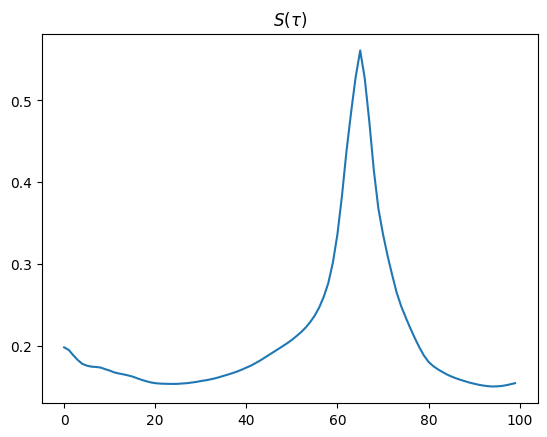

In [62]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau)
axs.set_title(r'$S(\tau)$')

plt.show()

Our example time series are always in PS, because we defined them to be so. However, $S(\tau)$ is highly dependent on the delay. Visually, we could see from the RPs if there is PS or not by judging the spacing between diagonals. Nevertheless, this is not a strong criteria. $S(\tau)$ will not necessarily be high even if we have PS. The max value can be probably attributed to the time where our lagged time series has gone through a full period and completely coincides with the unlagged one. 


Open questions:

- Does something change if we shorten time series 1 or time series 2?
- Should we try Rényi entropy?


### Summary
JRP(0) and JRP($\tau$)
- JRPs give us a weak signal of PS. Two systems at PS may or may not have crowded recurrence plots, depending on whether individual recurrences (small structures) overlap or not. Two systems may have the same phase, and its small structures not overlap, producing thus an empty JRP despite having PS. 


$S(0)$
- $S(0)$ cannot tell us if there is PS or not. In general, S values vary for systems that are defined to be in PS, showing it's unsuitability to determine it. 


$S(\tau)$
- A caveat is that it requires us to shorten the time series to apply the lag, thus losing information. Care has to be taken to balance loss of information and amount of lag desired. This could lead to difficulties when working with experimental data, where time series cannot be lengthened arbitrarily. 
- In the best case, $S(\tau)$ could show when both RPs coincide the most. Even though this indicates PS, the inverse is not true: two plots in PS will not necessarily have a high $S(\tau)$. CPR is better for determining PS because it focuses solely on the frequency of diagonals, and its individual structures are not as important as in the $S(\tau)$ measure. 

- JRP (and $S(\tau)$) will tell me if the frequencies are similar, it will tell me at which lag both RPs will be more similar, but it is highly dependent on the individual shape of the recurrences (when compared to the CPR). For instance, two time series whose phase difference is constant, but whose individual recurrences don't coincide in the recurrence plot, may show a really low $S(\tau)$.



- Apparently, the joint Rényi entropy of second order K2, which is measured from the JRP, does show PS (Romano, 2004). Something to explore later...
- Try also JPR instead of $S(\tau)$. (Marwan, 2007) Still, JPR clearly not as effective as CPR. Actually, individual values of JPR are still low despite systems being in PS (Marwan, 2007). I still think JPR is not a good indicator of PS, despite Marwan, 2007, suggesting it may be. It reacts to PS, but alone wouldn't be enough to know if it's occuring. 

## Structured analysis after meeting

In [30]:
#Import models
nosynch1 = pd.read_csv('timeseries/PS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('timeseries/PS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('timeseries/PS_synch1.csv').to_numpy()

synch2 = pd.read_csv('timeseries/PS_synch2.csv').to_numpy()

In [31]:
#View the individual recurrence plots
#No synch
rec_nosynch1 = RecurrencePlot(nosynch1, recurrence_rate=0.1, metric="euclidean")
rm_nosynch1 = rec_nosynch1.recurrence_matrix()

rec_nosynch2 = RecurrencePlot(nosynch2, recurrence_rate=0.1, metric="euclidean")
rm_nosynch2 = rec_nosynch2.recurrence_matrix()

#Synch
rec_synch1 = RecurrencePlot(synch1, recurrence_rate=0.1, metric="euclidean")
rm_synch1 = rec_synch1.recurrence_matrix()

rec_synch2 = RecurrencePlot(synch2, recurrence_rate=0.1, metric="euclidean")
rm_synch2 = rec_synch2.recurrence_matrix()


Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


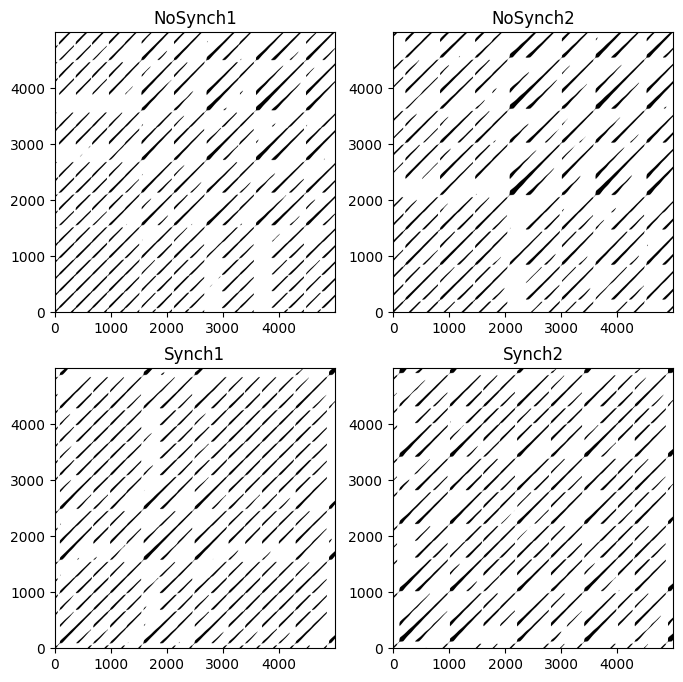

In [6]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

- A close look shows that the space between diagonals is not equal for NoSynch, whereas it is for Synch.
- Coincidence of individual recurrences not evident for Synch, although NoSynched plots differ in a greater degree.
- We expect NoSynch JRP to be less crowded due to differing frequencies. 

In [32]:
#Compute JRPs
#No synch
LS_JR_nosynch = JointRecurrencePlot(nosynch1, nosynch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_nosynch = LS_JR_nosynch.recurrence_matrix()

#Synch
LS_JR_synch = JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_synch = LS_JR_synch.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


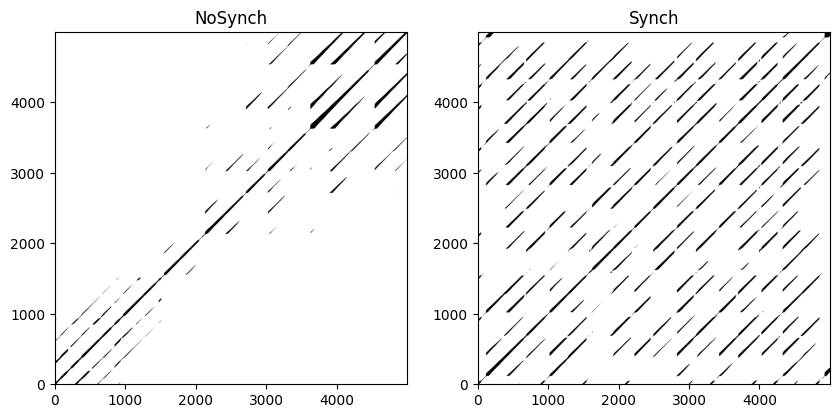

In [8]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title('NoSynch')

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title('Synch')


plt.show()

- Synched JRP much more crowded than NoSynch. This is in part, because at least it's both's systems frequencies are similar, which is what determines the spacing between the diagonals. 

Pending: $JRP(\tau)$ analysis

### $S(\tau)$ analysis

In [33]:
print('S(0) NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('S(0) Synch', LS_JR_synch.recurrence_rate()/0.1)

S(0) NoSynch 0.1918096
S(0) Synch 0.5718344


$S(0)$ shows different between Synch and NoSynch, but it's values are low even for the synched system. It is not as clear as for, for example, LS.

In [34]:
lagged_JR_synch = [JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = i) for i in range(60)]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

In [35]:
s_tau_synch = [lagged_JR_synch[i].recurrence_rate()/0.1 for i in range(len(lagged_JR_synch))]

In [36]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_JR_synch[max_lag]

RMat_max_JRP_tau  = max_JRP_tau.recurrence_matrix()

In [37]:
print('JRP NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('JRP(0)',s_tau_synch[0])
print('JRP(tau)',max(s_tau_synch))

JRP NoSynch 0.1918096
JRP(0) 0.5718344
JRP(tau) 0.5978192


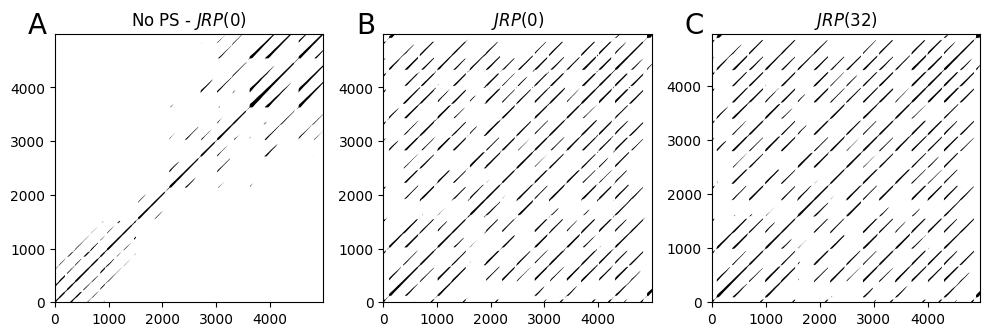

In [11]:
#Visualize
fig, axs = plt.subplots(1,3,figsize=(10, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No PS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)

axs[2].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[2].set_title(r'$JRP({})$'.format(max_lag))
axs[2].text(-0.1, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
fig.savefig('plots/JRPs_PS.png')

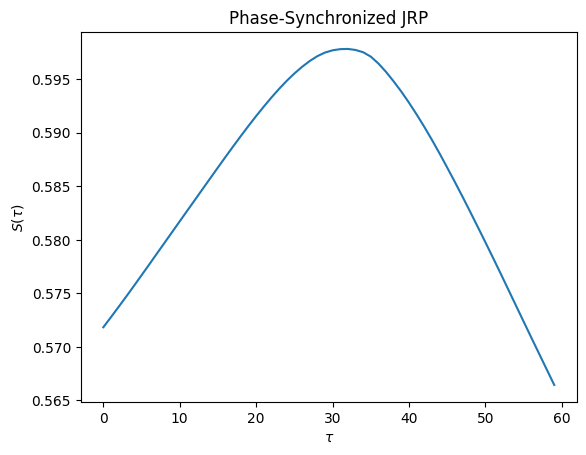

In [12]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau_synch)
axs.set_xlabel(r'$\tau$')
axs.set_ylabel(r'$S(\tau)$')
axs.set_title(r'Phase-Synchronized JRP')

plt.show()

fig.savefig('plots/PS_S_tau.png')

- We do see a sensibility of $S(\tau)$ to the lag, but it itself is not enough to determine PS.

Let's compute JRPs when $S(\tau)$ is max.

In [28]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_JR_synch[max_lag]

RMat_max_JRP_tau  = max_JRP_tau.recurrence_matrix()

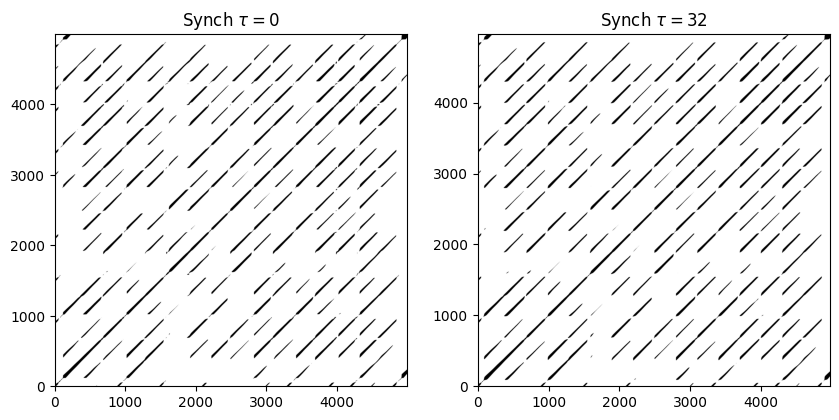

In [29]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

axs[0].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[0].set_title(r'Synch $\tau = 0$')

axs[1].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[1].set_title(r'Synch $\tau = {}$'.format(max_lag))


plt.show()

- Difference is not visually evident, and that's expressed in the little difference in $S(\tau)$ coefficients.   
- Is the crowdedness of a JRP in PS merely chance? Or is there a rule? Why are the values of $S(\tau)$ always around the same? 


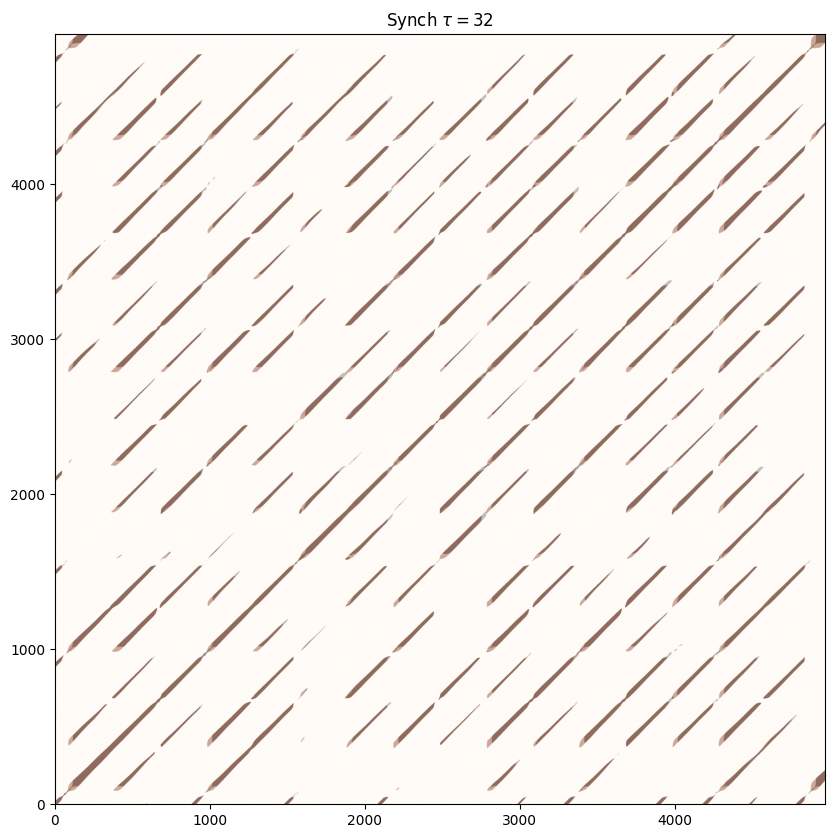

In [50]:
#Visualize
fig, axs = plt.subplots(figsize=(10, 10))

axs.imshow(RMat_LS_synch, origin='lower', cmap = 'binary', alpha = 0.4)

axs.imshow(RMat_max_JRP_tau, origin='lower', cmap = 'Oranges', alpha = 0.4)
axs.set_title(r'Synch $\tau = {}$'.format(max_lag))


plt.show()

- What changes between the $JRP(0)$ and the $JRP(\tau_{max})$ is the length of the diagonals. This is due to the expected diagonal shift of recurrences until a maximum coincidence occurs. The appearance of new diagonals is not evident. 

Evaluation of sensitivity of $S(\tau)$ to coupling

In [13]:
#Mutually coupled Roessler systems
#taken from Marwan (2007), eqs. A.9 and A.10
def coupled_Roessler(t, X, a, b, c, nu, mu):
    """
    X is a flattened vector [x1, x2, x3, y1, y2, y3].
    x corresponds to the first system, y corresponds to the 
    second one. 
    """
    dX = np.zeros(len(X))

    #First system (A.9)
    dX[0] = -(1 + nu)*X[1] - X[2]
    dX[1] = (1 + nu)*X[0] + a*X[1] + mu*(X[4] - X[1])
    dX[2] = b + X[2]*(X[0] - c)

    #Second system (A.10)
    dX[3] = -(1 - nu)*X[4] - X[5]
    dX[4] = (1 - nu)*X[3] + a*X[4] + mu*(X[1] - X[4])
    dX[5] = b + X[5]*(X[3] - c)

    return dX

In [18]:
# Parametres phase coherent regime
# Marwan (2007, p. 290)


a, b, c = 0.16, 0.1, 8.5
#a, b, c = 0.2, 0.2, 5.7
nu = 0.02
mu = np.arange(0,0.15,0.005)


"""
a, b, c = 0.2925, 0.1, 8.5
nu = 0.02
mu = 0.2
"""

#Timestep and length not specified in paper
"""
1000 time steps was to short to show behaviour. We let it stabilize
for 5000 timesteps and use the remaining 10000
"""
T = 15000*0.02  #
dt = 0.02 #Bigger dt gave too rough of a plot
#dt = 0.04 #Bigger dt gave too rough of a plot

In [19]:
# Numerically Integrate The System States
#Initial conditions not specified
X0 = [0,0,0,0,0,0]

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sols = [solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, mu[i]), method="RK45") for i in range(len(mu))]

In [20]:
#Separate models
synch1_varied_coupling = [sols[i].y[:3].T[10000:] for i in range(len(sols))]
synch2_varied_coupling = [sols[i].y[3:].T[10000:] for i in range(len(sols))]

In [21]:
from tqdm import tqdm

JPR_list = []

lags = np.arange(0,50,2)

for i in tqdm(range(len(synch1_varied_coupling))):
    #We already know around where Smax is reached
    #lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(30)]
    lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in lags]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)

  0%|          | 0/30 [00:00<?, ?it/s]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

  3%|▎         | 1/30 [01:41<49:01, 101.44s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

  7%|▋         | 2/30 [03:24<47:51, 102.57s/it]

...

 93%|█████████▎| 28/30 [47:32<03:22, 101.49s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

 97%|█████████▋| 29/30 [49:14<01:41, 101.64s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

100%|██████████| 30/30 [50:55<00:00, 101.85s/it]


In [22]:
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("PS_JPR_list.csv", index=False)

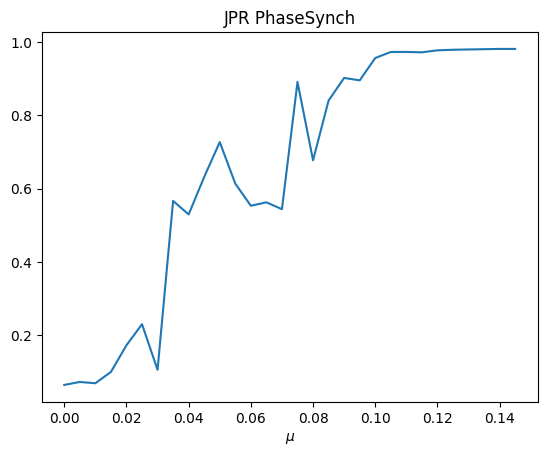

In [23]:
fig, axs = plt.subplots()

#Plot
axs.plot(mu,JPR_list)
axs.set_xlabel(r"$\mu$")
axs.set_title(r'JPR PhaseSynch')

plt.show()

- JPR shows sensitivity to PS. However, it seems to be weaker than CPR for the same parameters (check graph at Roessler_PS.ipynb doc).

In [24]:
CPR_list = []

for i in tqdm(range(len(mu))):

    rp_drive = RecurrencePlot(synch1_varied_coupling[i], metric="euclidean", recurrence_rate=0.1)
    rp_response = RecurrencePlot(synch2_varied_coupling[i], metric="euclidean", recurrence_rate=0.1)

    RP_drive = rp_drive.recurrence_matrix()
    RP_response = rp_response.recurrence_matrix()

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

  0%|          | 0/30 [00:00<?, ?it/s]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  3%|▎         | 1/30 [00:04<01:58,  4.09s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  7%|▋         | 2/30 [00:08<01:52,  4.03s/it]

...

 93%|█████████▎| 28/30 [01:55<00:08,  4.11s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


 97%|█████████▋| 29/30 [01:59<00:04,  4.12s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


100%|██████████| 30/30 [02:03<00:00,  4.11s/it]


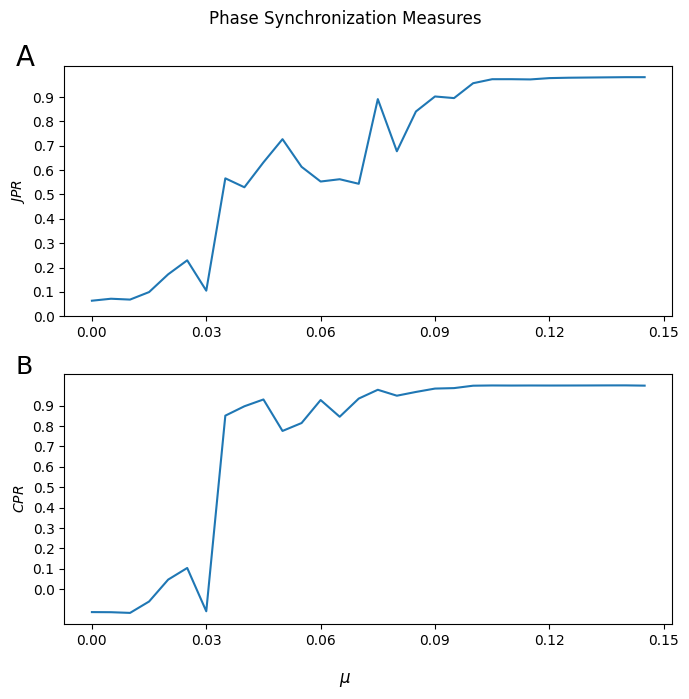

In [29]:
fig, axs = plt.subplots(2,1,figsize=(7, 7))

#JPR
axs[0].plot(mu,JPR_list)
axs[0].set_yticks(np.arange(0,1,0.1))
axs[0].set_xticks(np.arange(0,0.16,0.03))
axs[0].set_ylabel(r"$JPR$")
axs[0].text(-0.08, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)


#CPR
axs[1].plot(mu,CPR_list)
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,0.16,0.03))
axs[1].set_ylabel(r"$CPR$")
axs[1].text(-0.08, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=18)

fig.suptitle('Phase Synchronization Measures')
fig.supxlabel(r"$\mu$")

plt.tight_layout()
plt.show()


fig.savefig('plots/PS_JPRandCPR.png')